<a href="https://colab.research.google.com/github/MinjanaAP/Long-Jump-Performance-Analysis/blob/main/Module2_InjuryRisk_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install faker

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 33.5 MB/s eta 0:00:00


In [3]:
import pandas as pd
import numpy as np
import random
from faker import Faker

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

In [4]:
OPTIMAL_RANGES = {
    "projection_angle": (18, 24),
    "lead_leg_thigh_angle": (65, 85),
    "minimum_knee_angle": (145, 165),
    "landing_knee_flexion": (90, 120),
    "trunk_angle": (10, 25)
}

In [5]:
fake = Faker()

data = []

for i in range(500):

    athlete_id = f"A{i+1:03}"

    age = random.randint(18, 30)

    projection_angle = round(random.uniform(10, 30), 2)
    lead_leg_thigh_angle = round(random.uniform(40, 100), 2)
    minimum_knee_angle = round(random.uniform(120, 175), 2)
    landing_knee_flexion = round(random.uniform(60, 140), 2)
    trunk_angle = round(random.uniform(0, 40), 2)

    previous_injury = random.choice([0, 1])

    # Technique Error Calculation
    error_score = (
        abs(projection_angle - 21) +
        abs(lead_leg_thigh_angle - 75) +
        abs(minimum_knee_angle - 155) +
        abs(landing_knee_flexion - 105) +
        abs(trunk_angle - 18)
    )

    # Injury Risk Logic
    if error_score < 40 and previous_injury == 0:
        injury_risk = "Low"
        injury_type = "None"

    elif error_score < 70:
        injury_risk = "Medium"
        injury_type = random.choice([
            "Ankle Sprain",
            "Hamstring Strain"
        ])

    else:
        injury_risk = "High"
        injury_type = random.choice([
            "Ankle Sprain",
            "Hamstring Strain",
            "Knee Injury"
        ])

    data.append([
        athlete_id,
        age,
        projection_angle,
        lead_leg_thigh_angle,
        minimum_knee_angle,
        landing_knee_flexion,
        trunk_angle,
        previous_injury,
        injury_type,
        injury_risk
    ])

In [6]:
columns = [
    "athlete_id",
    "age",
    "projection_angle",
    "lead_leg_thigh_angle",
    "minimum_knee_angle",
    "landing_knee_flexion",
    "trunk_angle",
    "previous_injury",
    "injury_type",
    "injury_risk"
]

df = pd.DataFrame(data, columns=columns)

df.head()

,athlete_id,age,projection_angle,lead_leg_thigh_angle,minimum_knee_angle,landing_knee_flexion,trunk_angle,previous_injury,injury_type,injury_risk
0,A001,27,21.82,62.80,172.51,75.57,15.51,0,Hamstring Strain,Medium
1,A002,23,17.14,55.46,171.00,98.20,23.79,0,Ankle Sprain,Medium
2,A003,28,22.18,59.41,169.10,95.25,28.29,0,Ankle Sprain,Medium
3,A004,21,10.32,80.03,132.55,102.27,17.47,1,Ankle Sprain,Medium
4,A005,21,23.39,93.36,170.76,120.99,9.39,0,Ankle Sprain,Medium


In [7]:
df.to_csv("synthetic_longjump_dataset.csv", index=False)

**Data Preprocessing**
1. Check Missing Values

In [8]:
df.isnull().sum()

,0
athlete_id,0
age,0
projection_angle,0
lead_leg_thigh_angle,0
minimum_knee_angle,0
landing_knee_flexion,0
trunk_angle,0
previous_injury,0
injury_type,0
injury_risk,0


2. Encode Categorical Data
| Original | Encoded |
| -------- | ------- |
| Low      | 0       |
| Medium   | 1       |
| High     | 2       |


2.1. Step 1 — Add angle error features

In [9]:
benchmarks = {
    "projection_angle": 21,
    "lead_leg_thigh_angle": 75,
    "minimum_knee_angle": 155,
    "landing_knee_flexion": 105,
    "trunk_angle": 18
}

df["projection_angle_error"] = abs(df["projection_angle"] - benchmarks["projection_angle"])
df["lead_leg_thigh_angle_error"] = abs(df["lead_leg_thigh_angle"] - benchmarks["lead_leg_thigh_angle"])
df["minimum_knee_angle_error"] = abs(df["minimum_knee_angle"] - benchmarks["minimum_knee_angle"])
df["landing_knee_flexion_error"] = abs(df["landing_knee_flexion"] - benchmarks["landing_knee_flexion"])
df["trunk_angle_error"] = abs(df["trunk_angle"] - benchmarks["trunk_angle"])

df["total_technique_error"] = (
    df["projection_angle_error"] +
    df["lead_leg_thigh_angle_error"] +
    df["minimum_knee_angle_error"] +
    df["landing_knee_flexion_error"] +
    df["trunk_angle_error"]
)

df.head()

,athlete_id,age,projection_angle,lead_leg_thigh_angle,minimum_knee_angle,landing_knee_flexion,trunk_angle,previous_injury,injury_type,injury_risk,projection_angle_error,lead_leg_thigh_angle_error,minimum_knee_angle_error,landing_knee_flexion_error,trunk_angle_error,total_technique_error
0,A001,27,21.82,62.80,172.51,75.57,15.51,0,Hamstring Strain,Medium,0.82,12.20,17.51,29.43,2.49,62.45
1,A002,23,17.14,55.46,171.00,98.20,23.79,0,Ankle Sprain,Medium,3.86,19.54,16.00,6.80,5.79,51.99
2,A003,28,22.18,59.41,169.10,95.25,28.29,0,Ankle Sprain,Medium,1.18,15.59,14.10,9.75,10.29,50.91
3,A004,21,10.32,80.03,132.55,102.27,17.47,1,Ankle Sprain,Medium,10.68,5.03,22.45,2.73,0.53,41.42
4,A005,21,23.39,93.36,170.76,120.99,9.39,0,Ankle Sprain,Medium,2.39,18.36,15.76,15.99,8.61,61.11


2.2. Step 2 — Encode injury risk and injury type

In [10]:
from sklearn.preprocessing import LabelEncoder

risk_encoder = LabelEncoder()
type_encoder = LabelEncoder()

df["injury_risk_encoded"] = risk_encoder.fit_transform(df["injury_risk"])
df["injury_type_encoded"] = type_encoder.fit_transform(df["injury_type"])

print(dict(zip(risk_encoder.classes_, risk_encoder.transform(risk_encoder.classes_))))
print(dict(zip(type_encoder.classes_, type_encoder.transform(type_encoder.classes_))))

{'High': np.int64(0), 'Low': np.int64(1), 'Medium': np.int64(2)}
{'Ankle Sprain': np.int64(0), 'Hamstring Strain': np.int64(1), 'Knee Injury': np.int64(2), 'None': np.int64(3)}


3. Define inputs and two prediction targets

In [11]:
feature_columns = [
    "age",
    "projection_angle",
    "lead_leg_thigh_angle",
    "minimum_knee_angle",
    "landing_knee_flexion",
    "trunk_angle",
    "projection_angle_error",
    "lead_leg_thigh_angle_error",
    "minimum_knee_angle_error",
    "landing_knee_flexion_error",
    "trunk_angle_error",
    "total_technique_error",
    "previous_injury"
]

X = df[feature_columns]

y_risk = df["injury_risk_encoded"]
y_type = df["injury_type_encoded"]

4. Train-Test Split

| Dataset       | Purpose              |
| ------------- | -------------------- |
| Training Data | Learn patterns       |
| Testing Data  | Evaluate performance |


In [12]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_risk_train, y_risk_test, y_type_train, y_type_test = train_test_split(
    X,
    y_risk,
    y_type,
    test_size=0.2,
    random_state=42,
    stratify=y_risk
)

5. Feature Scaling


> (value - mean) / standard deviation

*all values are brought into a similar range.*



In [13]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

**Train Machine Learning Models**

0. Common evaluation function

In [14]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import pandas as pd

model_results = []

def evaluate_model(model_name, y_test, y_pred, labels):
    print(f"\n===== {model_name} =====")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, target_names=labels))

    ConfusionMatrixDisplay.from_predictions(
        y_test,
        y_pred,
        display_labels=labels
    )
    plt.title(f"Confusion Matrix - {model_name}")
    plt.xticks(rotation=30)
    plt.show()

    return {
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, average="weighted"),
        "Recall": recall_score(y_test, y_pred, average="weighted"),
        "F1 Score": f1_score(y_test, y_pred, average="weighted")
    }

Visualize Injury Risk Distribution

---




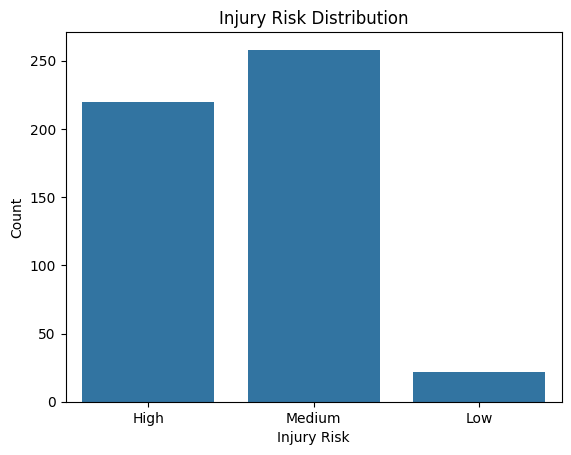

In [ ]:
sns.countplot(x='injury_risk', data=df)

plt.title("Injury Risk Distribution")
plt.xlabel("Injury Risk")
plt.ylabel("Count")

plt.show()

Visualize Angle Distributions

---



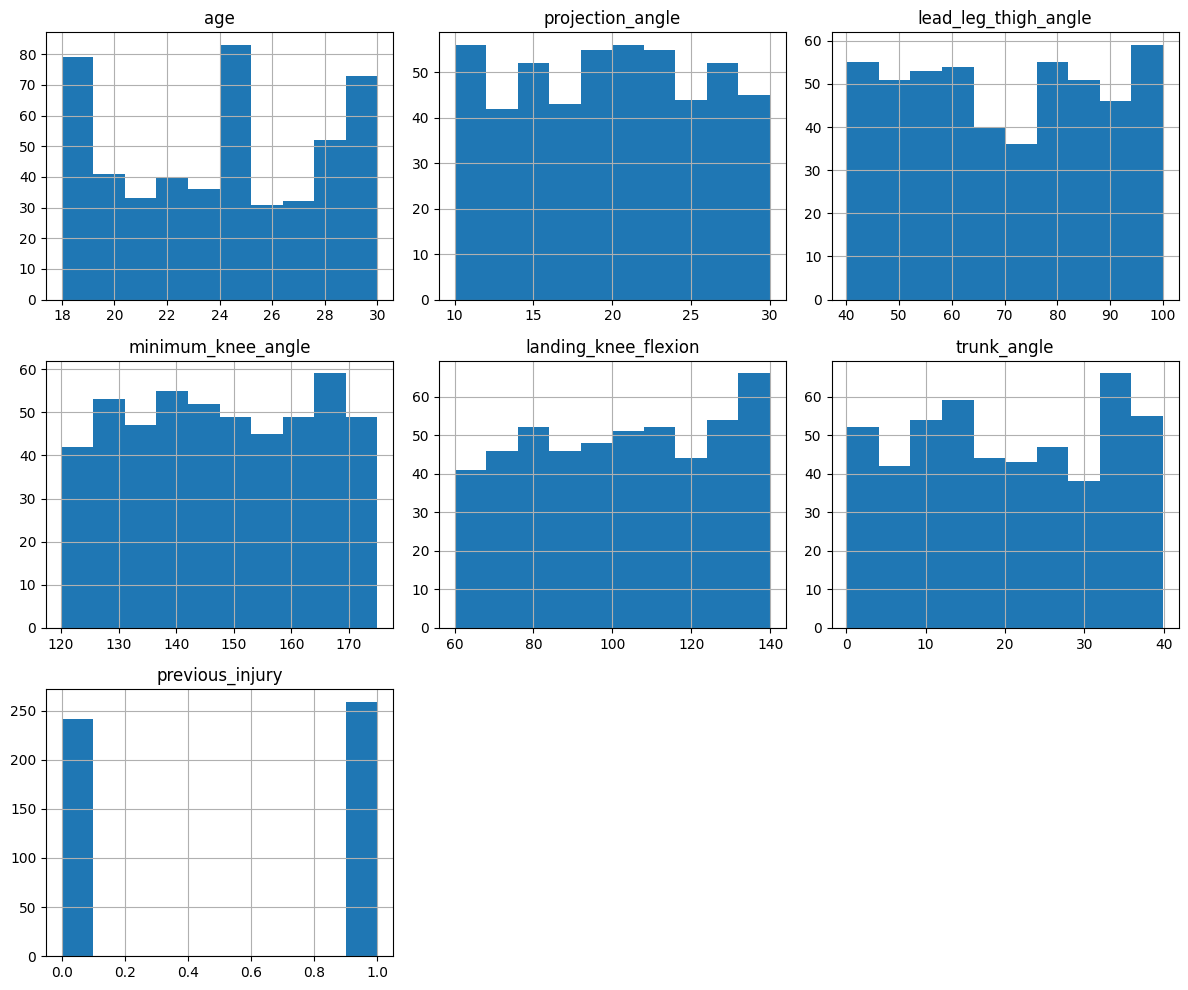

In [ ]:
df.hist(figsize=(12,10))

plt.tight_layout()
plt.show()

Correlation Heatmap

---



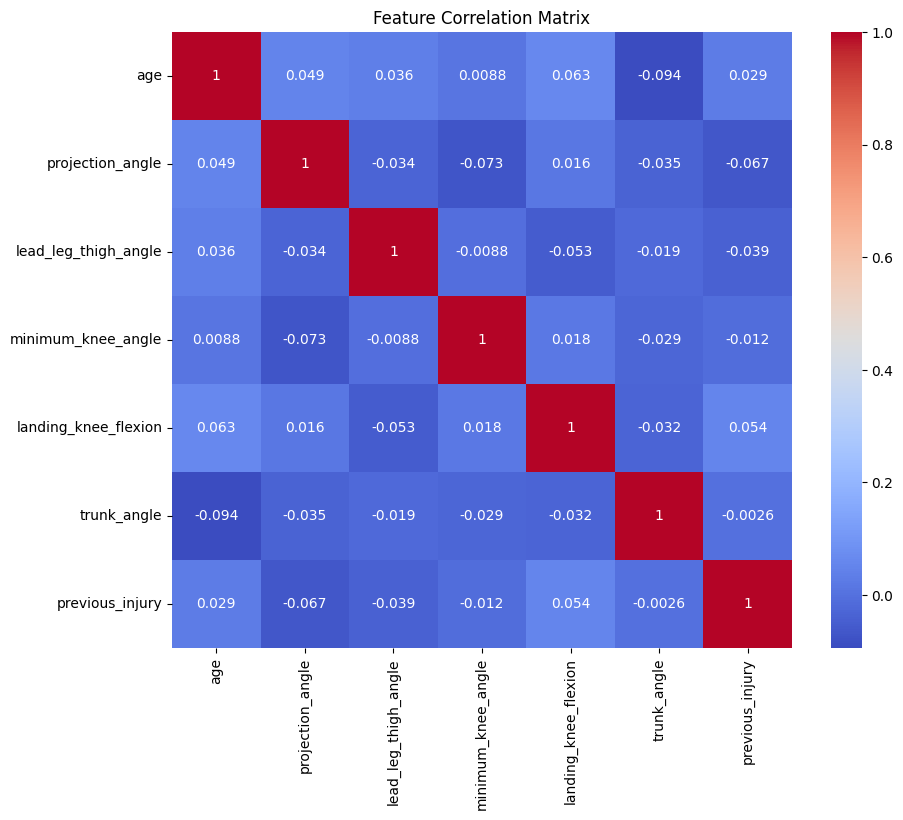

In [ ]:
plt.figure(figsize=(10,8))

sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap='coolwarm')

plt.title("Feature Correlation Matrix")

plt.show()

1. Logistic Regression


===== Logistic Regression - Risk Level =====
Accuracy: 0.96

Classification Report:
              precision    recall  f1-score   support

        High       0.98      0.98      0.98        45
         Low       1.00      0.33      0.50         3
      Medium       0.94      0.98      0.96        52

    accuracy                           0.96       100
   macro avg       0.97      0.76      0.81       100
weighted avg       0.96      0.96      0.96       100



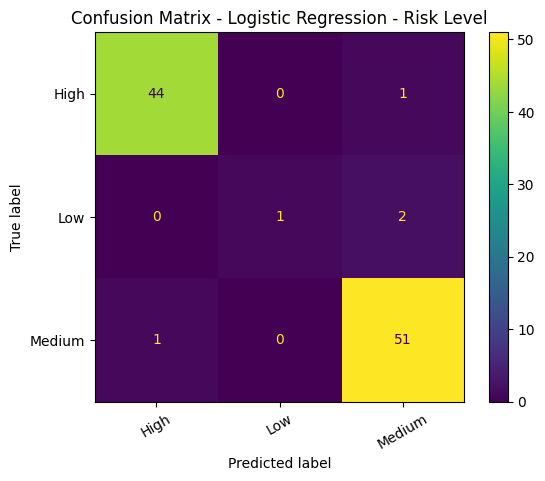


===== Logistic Regression - Injury Type =====
Accuracy: 0.43

Classification Report:
                  precision    recall  f1-score   support

    Ankle Sprain       0.44      0.41      0.43        39
Hamstring Strain       0.43      0.61      0.50        38
     Knee Injury       0.25      0.10      0.14        20
            None       1.00      0.67      0.80         3

        accuracy                           0.43       100
       macro avg       0.53      0.45      0.47       100
    weighted avg       0.42      0.43      0.41       100



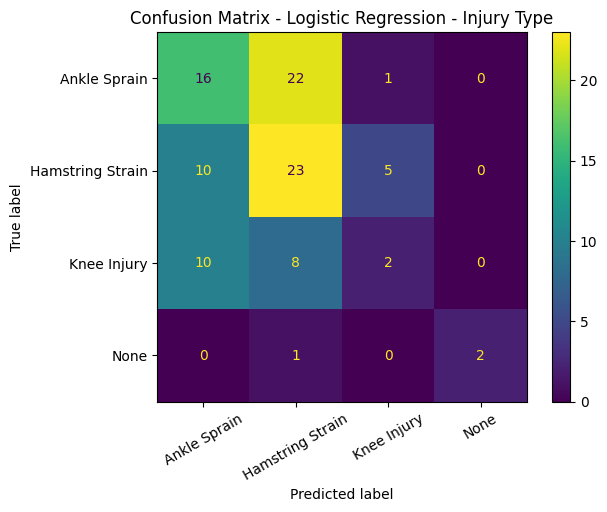

In [15]:
from sklearn.linear_model import LogisticRegression

lr_risk = LogisticRegression(max_iter=1000, random_state=42)
lr_type = LogisticRegression(max_iter=1000, random_state=42)

lr_risk.fit(X_train_scaled, y_risk_train)
lr_type.fit(X_train_scaled, y_type_train)

lr_risk_pred = lr_risk.predict(X_test_scaled)
lr_type_pred = lr_type.predict(X_test_scaled)

risk_lr_result = evaluate_model(
    "Logistic Regression - Risk Level",
    y_risk_test,
    lr_risk_pred,
    risk_encoder.classes_
)

type_lr_result = evaluate_model(
    "Logistic Regression - Injury Type",
    y_type_test,
    lr_type_pred,
    type_encoder.classes_
)

2. Random Forest


===== Random Forest - Risk Level =====
Accuracy: 0.98

Classification Report:
              precision    recall  f1-score   support

        High       1.00      1.00      1.00        45
         Low       1.00      0.33      0.50         3
      Medium       0.96      1.00      0.98        52

    accuracy                           0.98       100
   macro avg       0.99      0.78      0.83       100
weighted avg       0.98      0.98      0.98       100



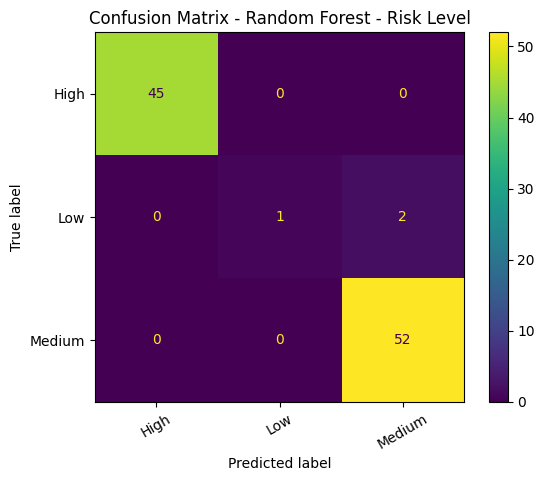


===== Random Forest - Injury Type =====
Accuracy: 0.39

Classification Report:
                  precision    recall  f1-score   support

    Ankle Sprain       0.35      0.44      0.39        39
Hamstring Strain       0.38      0.39      0.39        38
     Knee Injury       0.40      0.20      0.27        20
            None       1.00      1.00      1.00         3

        accuracy                           0.39       100
       macro avg       0.53      0.51      0.51       100
    weighted avg       0.39      0.39      0.38       100



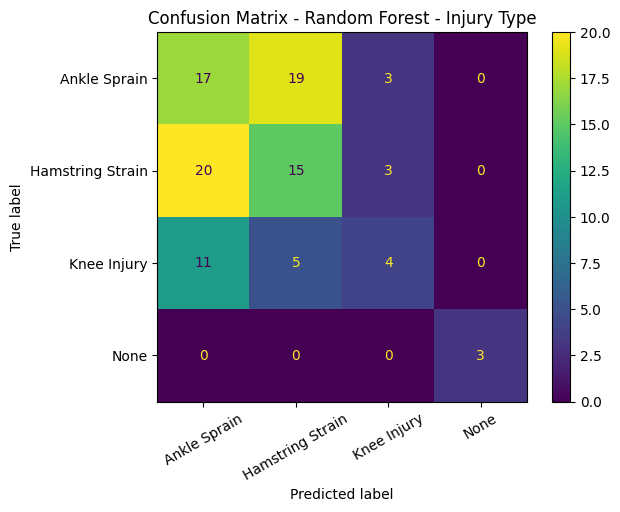

In [16]:
from sklearn.ensemble import RandomForestClassifier

rf_risk = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight="balanced"
)

rf_type = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight="balanced"
)

rf_risk.fit(X_train_scaled, y_risk_train)
rf_type.fit(X_train_scaled, y_type_train)

rf_risk_pred = rf_risk.predict(X_test_scaled)
rf_type_pred = rf_type.predict(X_test_scaled)

risk_rf_result = evaluate_model(
    "Random Forest - Risk Level",
    y_risk_test,
    rf_risk_pred,
    risk_encoder.classes_
)

type_rf_result = evaluate_model(
    "Random Forest - Injury Type",
    y_type_test,
    rf_type_pred,
    type_encoder.classes_
)

2.1. Feature importance:

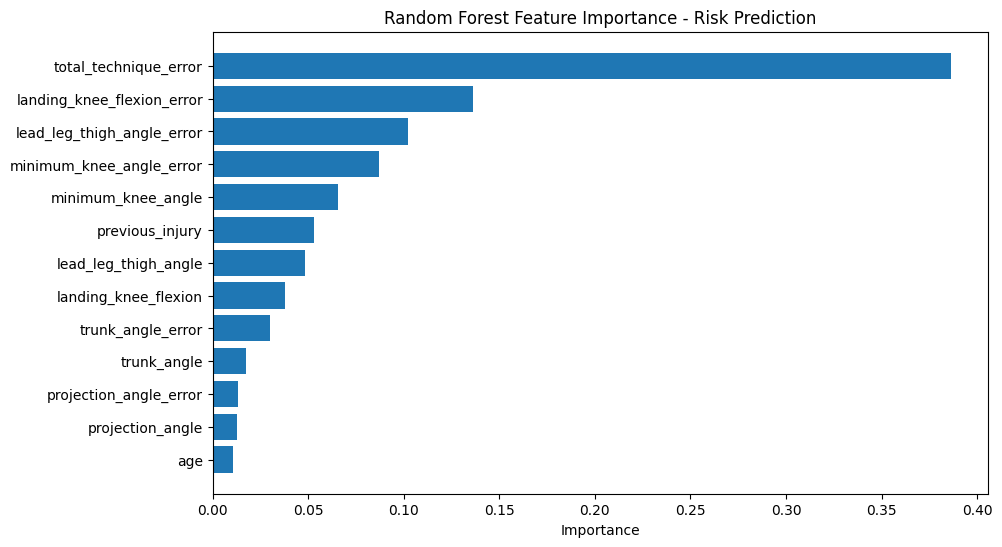

,Feature,Importance
11,total_technique_error,0.386246
9,landing_knee_flexion_error,0.135949
7,lead_leg_thigh_angle_error,0.101963
8,minimum_knee_angle_error,0.087241
3,minimum_knee_angle,0.065682
12,previous_injury,0.053045
2,lead_leg_thigh_angle,0.048500
4,landing_knee_flexion,0.037678
10,trunk_angle_error,0.029832
5,trunk_angle,0.017229


In [17]:
rf_importance = pd.DataFrame({
    "Feature": feature_columns,
    "Importance": rf_risk.feature_importances_
}).sort_values(by="Importance", ascending=False)

plt.figure(figsize=(10,6))
plt.barh(rf_importance["Feature"], rf_importance["Importance"])
plt.xlabel("Importance")
plt.title("Random Forest Feature Importance - Risk Prediction")
plt.gca().invert_yaxis()
plt.show()

rf_importance

3. XGBoost


===== XGBoost - Risk Level =====
Accuracy: 1.0

Classification Report:
              precision    recall  f1-score   support

        High       1.00      1.00      1.00        45
         Low       1.00      1.00      1.00         3
      Medium       1.00      1.00      1.00        52

    accuracy                           1.00       100
   macro avg       1.00      1.00      1.00       100
weighted avg       1.00      1.00      1.00       100



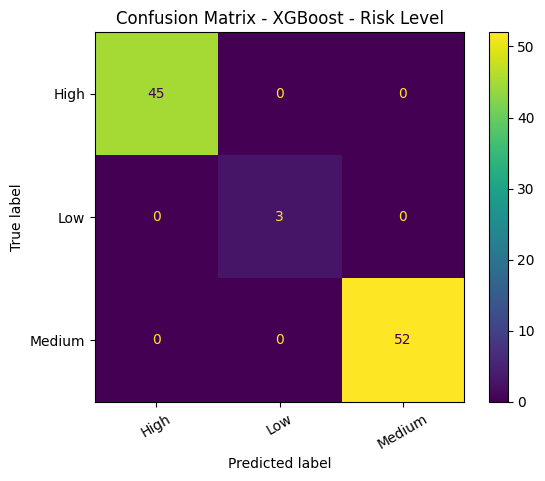


===== XGBoost - Injury Type =====
Accuracy: 0.5

Classification Report:
                  precision    recall  f1-score   support

    Ankle Sprain       0.47      0.41      0.44        39
Hamstring Strain       0.51      0.55      0.53        38
     Knee Injury       0.45      0.50      0.48        20
            None       1.00      1.00      1.00         3

        accuracy                           0.50       100
       macro avg       0.61      0.62      0.61       100
    weighted avg       0.50      0.50      0.50       100



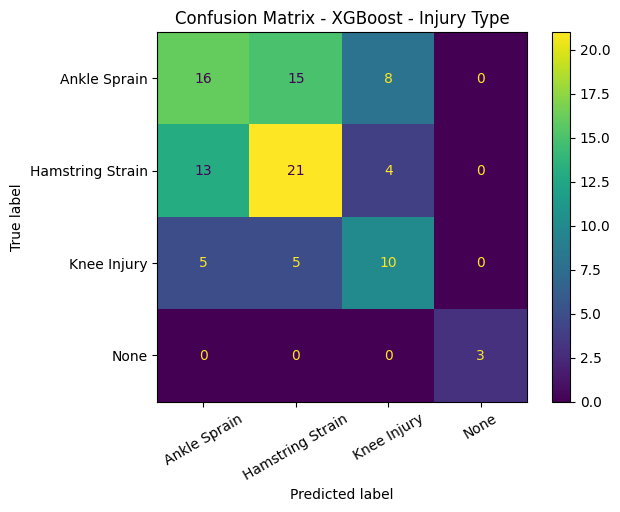

In [18]:
from xgboost import XGBClassifier

xgb_risk = XGBClassifier(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.1,
    eval_metric="mlogloss",
    random_state=42
)

xgb_type = XGBClassifier(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.1,
    eval_metric="mlogloss",
    random_state=42
)

xgb_risk.fit(X_train_scaled, y_risk_train)
xgb_type.fit(X_train_scaled, y_type_train)

xgb_risk_pred = xgb_risk.predict(X_test_scaled)
xgb_type_pred = xgb_type.predict(X_test_scaled)

risk_xgb_result = evaluate_model(
    "XGBoost - Risk Level",
    y_risk_test,
    xgb_risk_pred,
    risk_encoder.classes_
)

type_xgb_result = evaluate_model(
    "XGBoost - Injury Type",
    y_type_test,
    xgb_type_pred,
    type_encoder.classes_
)

4. Support Vector Machine


===== SVM - Risk Level =====
Accuracy: 0.96

Classification Report:
              precision    recall  f1-score   support

        High       0.96      0.98      0.97        45
         Low       0.75      1.00      0.86         3
      Medium       0.98      0.94      0.96        52

    accuracy                           0.96       100
   macro avg       0.90      0.97      0.93       100
weighted avg       0.96      0.96      0.96       100



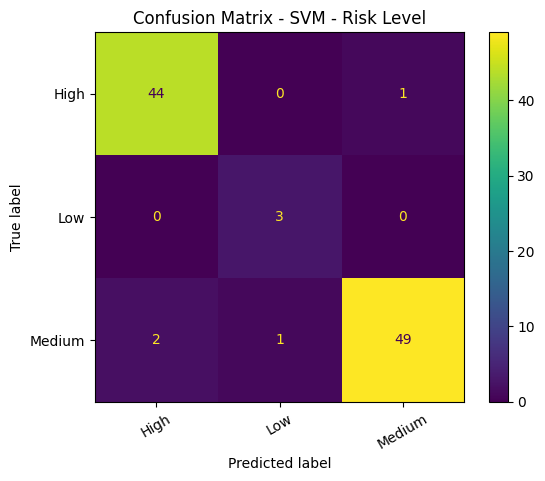


===== SVM - Injury Type =====
Accuracy: 0.42

Classification Report:
                  precision    recall  f1-score   support

    Ankle Sprain       0.39      0.36      0.37        39
Hamstring Strain       0.48      0.39      0.43        38
     Knee Injury       0.34      0.50      0.41        20
            None       0.75      1.00      0.86         3

        accuracy                           0.42       100
       macro avg       0.49      0.56      0.52       100
    weighted avg       0.43      0.42      0.42       100



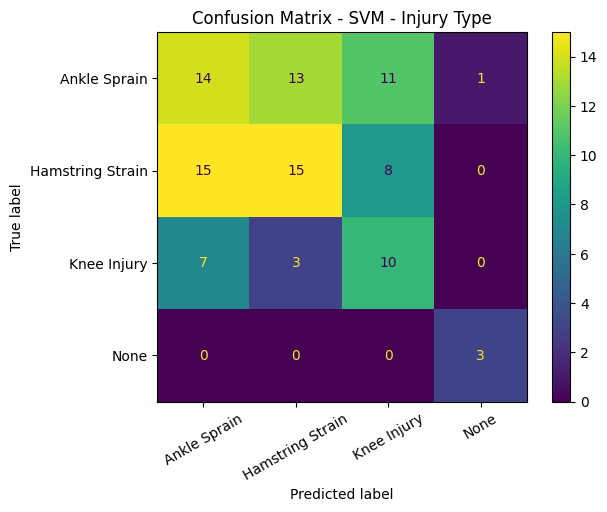

In [19]:
from sklearn.svm import SVC

svm_risk = SVC(
    kernel="rbf",
    probability=True,
    class_weight="balanced",
    random_state=42
)

svm_type = SVC(
    kernel="rbf",
    probability=True,
    class_weight="balanced",
    random_state=42
)

svm_risk.fit(X_train_scaled, y_risk_train)
svm_type.fit(X_train_scaled, y_type_train)

svm_risk_pred = svm_risk.predict(X_test_scaled)
svm_type_pred = svm_type.predict(X_test_scaled)

risk_svm_result = evaluate_model(
    "SVM - Risk Level",
    y_risk_test,
    svm_risk_pred,
    risk_encoder.classes_
)

type_svm_result = evaluate_model(
    "SVM - Injury Type",
    y_type_test,
    svm_type_pred,
    type_encoder.classes_
)

5. K-Nearest Neighbors


===== KNN - Risk Level =====
Accuracy: 0.84

Classification Report:
              precision    recall  f1-score   support

        High       0.94      0.73      0.82        45
         Low       1.00      0.33      0.50         3
      Medium       0.78      0.96      0.86        52

    accuracy                           0.84       100
   macro avg       0.91      0.68      0.73       100
weighted avg       0.86      0.84      0.83       100



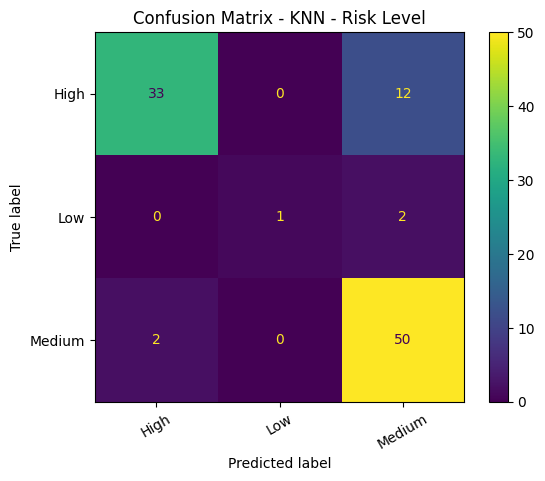


===== KNN - Injury Type =====
Accuracy: 0.39

Classification Report:
                  precision    recall  f1-score   support

    Ankle Sprain       0.37      0.51      0.43        39
Hamstring Strain       0.38      0.39      0.38        38
     Knee Injury       0.60      0.15      0.24        20
            None       1.00      0.33      0.50         3

        accuracy                           0.39       100
       macro avg       0.59      0.35      0.39       100
    weighted avg       0.44      0.39      0.38       100



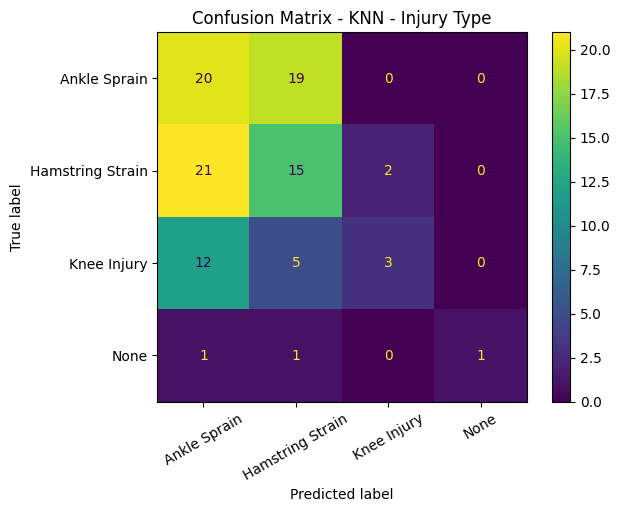

In [20]:
from sklearn.neighbors import KNeighborsClassifier

knn_risk = KNeighborsClassifier(n_neighbors=5)
knn_type = KNeighborsClassifier(n_neighbors=5)

knn_risk.fit(X_train_scaled, y_risk_train)
knn_type.fit(X_train_scaled, y_type_train)

knn_risk_pred = knn_risk.predict(X_test_scaled)
knn_type_pred = knn_type.predict(X_test_scaled)

risk_knn_result = evaluate_model(
    "KNN - Risk Level",
    y_risk_test,
    knn_risk_pred,
    risk_encoder.classes_
)

type_knn_result = evaluate_model(
    "KNN - Injury Type",
    y_type_test,
    knn_type_pred,
    type_encoder.classes_
)

**Final comparison table**

In [21]:
risk_results_df = pd.DataFrame([
    risk_lr_result,
    risk_rf_result,
    risk_xgb_result,
    risk_svm_result,
    risk_knn_result
]).sort_values(by="F1 Score", ascending=False)

type_results_df = pd.DataFrame([
    type_lr_result,
    type_rf_result,
    type_xgb_result,
    type_svm_result,
    type_knn_result
]).sort_values(by="F1 Score", ascending=False)

print("Risk Level Model Comparison")
display(risk_results_df)

print("Injury Type Model Comparison")
display(type_results_df)

Risk Level Model Comparison


,Model,Accuracy,Precision,Recall,F1 Score
2,XGBoost - Risk Level,1.00,1.000000,1.00,1.000000
1,Random Forest - Risk Level,0.98,0.980741,0.98,0.975189
3,SVM - Risk Level,0.96,0.962535,0.96,0.960487
0,Logistic Regression - Risk Level,0.96,0.961111,0.96,0.955377
4,KNN - Risk Level,0.84,0.860536,0.84,0.834526


Injury Type Model Comparison


,Model,Accuracy,Precision,Recall,F1 Score
2,XGBoost - Injury Type,0.50,0.499073,0.50,0.498222
3,SVM - Injury Type,0.42,0.427003,0.42,0.418164
0,Logistic Regression - Injury Type,0.43,0.415185,0.43,0.408971
1,Random Forest - Injury Type,0.39,0.394279,0.39,0.383799
4,KNN - Injury Type,0.39,0.436944,0.39,0.376896


**Visualize final comparison**

In [24]:
risk_results_df = pd.DataFrame([
    risk_lr_result,
    risk_rf_result,
    risk_xgb_result,
    risk_svm_result,
    risk_knn_result
]).sort_values(by="F1 Score", ascending=False)

type_results_df = pd.DataFrame([
    type_lr_result,
    type_rf_result,
    type_xgb_result,
    type_svm_result,
    type_knn_result
]).sort_values(by="F1 Score", ascending=False)

print("Risk Level Model Comparison")
display(risk_results_df)

print("Injury Type Model Comparison")
display(type_results_df)

Risk Level Model Comparison


,Model,Accuracy,Precision,Recall,F1 Score
2,XGBoost - Risk Level,1.00,1.000000,1.00,1.000000
1,Random Forest - Risk Level,0.98,0.980741,0.98,0.975189
3,SVM - Risk Level,0.96,0.962535,0.96,0.960487
0,Logistic Regression - Risk Level,0.96,0.961111,0.96,0.955377
4,KNN - Risk Level,0.84,0.860536,0.84,0.834526


Injury Type Model Comparison


,Model,Accuracy,Precision,Recall,F1 Score
2,XGBoost - Injury Type,0.50,0.499073,0.50,0.498222
3,SVM - Injury Type,0.42,0.427003,0.42,0.418164
0,Logistic Regression - Injury Type,0.43,0.415185,0.43,0.408971
1,Random Forest - Injury Type,0.39,0.394279,0.39,0.383799
4,KNN - Injury Type,0.39,0.436944,0.39,0.376896


**Select best models**

In [23]:
best_risk_model_name = risk_results_df.iloc[0]["Model"]
best_type_model_name = type_results_df.iloc[0]["Model"]

print("Best model for risk level prediction:", best_risk_model_name)
print("Best model for injury type prediction:", best_type_model_name)

Best model for risk level prediction: XGBoost - Risk Level
Best model for injury type prediction: XGBoost - Injury Type
